In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"
import re
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="paper")

In [2]:
ENTROPY_CSV = "wandb/wandb_export_entropy.csv"
LENGTH_CSV  = "wandb/wandb_export_mean_length.csv"
REWARD_CSV  = "wandb/wandb_export_reward.csv"
REWARD_STD_CSV  = "wandb/wandb_export_reward_std.csv"

ENTROPY_KEY = "train/entropy"
LENGTH_KEY  = "mean_length"
REWARD_KEY = "train/reward"
REWARD_STD_KEY = "train/reward_std"

In [3]:
column_mapping = {
    "qwen2.5 3B nacc inc oversample dedup": "LUNAR - OS - SCe",
    "qwen2.5 3B nacc inc oversample dedup sce tanh": "LUNAR - OS",
    "qwen2.5 3B nacc inc oversample": "LUNAR - SCe",
    "qwen2.5 3B nacc inc oversample sce tanh cont": "LUNAR",
}

In [4]:
def load_and_clean_metric_csv(path: str, metric_key: str):
    """
    - Loads a W&B export CSV
    - Keeps only train/global_step + mean metric columns (no __MIN/__MAX)
    - Renames columns so only the run name remains
    """
    df = pd.read_csv(path)

    # Ensure step is numeric
    df["train/global_step"] = pd.to_numeric(df["train/global_step"], errors="coerce")

    # Select metric columns (exclude MIN/MAX)
    metric_cols = [
        c for c in df.columns
        if metric_key in c and "__MIN" not in c and "__MAX" not in c
    ]

    if not metric_cols:
        raise ValueError(f"No columns found for metric '{metric_key}' in {path}")

    # Keep only step + metric columns
    df = df[["train/global_step"] + metric_cols]

    # Strip metric suffix from column names, keep only run name
    rename_map = {}
    for c in metric_cols:
        run_name = c.split("-")[0].strip()
        rename_map[c] = run_name

    df = df.rename(columns=rename_map)
    
    cont_col = "qwen2.5 3B nacc inc oversample sce tanh cont"
    base_col = "qwen2.5 3B nacc inc oversample sce tanh"

    df[cont_col] = df[cont_col].combine_first(df[base_col])
    
    df = df.drop(columns=[base_col])
    
    df = df.rename(columns=column_mapping)

    return df

In [5]:
df_entropy = load_and_clean_metric_csv(
    ENTROPY_CSV,
    metric_key=ENTROPY_KEY,
)

df_length = load_and_clean_metric_csv(
    LENGTH_CSV,
    metric_key=LENGTH_KEY,  # change if needed
)

df_reward = load_and_clean_metric_csv(
    REWARD_CSV,
    metric_key=REWARD_KEY,  # change if needed
)

df_reward_std = load_and_clean_metric_csv(
    REWARD_STD_CSV,
    metric_key=REWARD_STD_KEY,  # change if needed
)

In [6]:
order = ["LUNAR - OS - SCe", "LUNAR - OS", "LUNAR - SCe", "LUNAR"]

def to_long(df: pd.DataFrame, value_name: str):
    return df.melt(
        id_vars="train/global_step",
        value_vars=order,
        var_name="Variant",
        value_name=value_name,
    )

def smooth_long(df_long: pd.DataFrame, value_col: str, window: int = 25):
    df_long = df_long.sort_values("train/global_step")
    df_long[value_col] = (
        df_long
        .groupby("Variant")[value_col]
        .transform(lambda s: s.rolling(window, min_periods=1).mean())
    )
    return df_long


def smooth_long_ema_stop_at_end(
    df_long: pd.DataFrame,
    value_col: str,
    step_col: str = "train/global_step",
    alpha: float = 0.0005,
):
    df_long = df_long.sort_values(["Variant", step_col]).copy()

    def ema_one_variant(g):
        values = g[value_col].to_numpy()

        out = np.full(len(values), np.nan, dtype=float)

        # start at first non-NaN
        start = np.argmax(~np.isnan(values)) if np.any(~np.isnan(values)) else None
        if start is None:
            return pd.Series(out, index=g.index)

        ema = values[start]
        out[start] = ema

        for i in range(start + 1, len(values)):
            if np.isnan(values[i]):
                out[i] = np.nan
                continue

            ema = (1.0 - alpha) * ema + alpha * values[i]
            out[i] = ema

        return pd.Series(out, index=g.index)

    df_long[value_col] = (
        df_long.groupby("Variant", group_keys=False)
               .apply(ema_one_variant)
    )
    return df_long



In [7]:
entropy_long = to_long(df_entropy, "Entropy")
length_long  = to_long(df_length,  "Mean response length")
reward_long  = to_long(df_reward,  "Group rewards")
reward_std_long  = to_long(df_reward_std,  "Group rewards std")

# entropy_long = smooth_long(entropy_long, "Entropy", window=50)
# length_long  = smooth_long(length_long,  "Mean response length", window=50)
# reward_long  = smooth_long(reward_long,  "Group rewards", window=10)

entropy_long = smooth_long_ema_stop_at_end(
    entropy_long,
    value_col="Entropy",
    alpha=0.01,
)

length_long = smooth_long_ema_stop_at_end(
    length_long,
    value_col="Mean response length",
    alpha=0.01,
)

reward_long = smooth_long_ema_stop_at_end(
    reward_long,
    value_col="Group rewards",
    alpha=0.01,
)

reward_std_long = smooth_long_ema_stop_at_end(
    reward_std_long,
    value_col="Group rewards std",
    alpha=0.01,
)


/scratch/ipykernel_3385840/1158606092.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ema_one_variant)
/scratch/ipykernel_3385840/1158606092.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ema_one_variant)
/scratch/ipykernel_3385840/1158606092.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pa

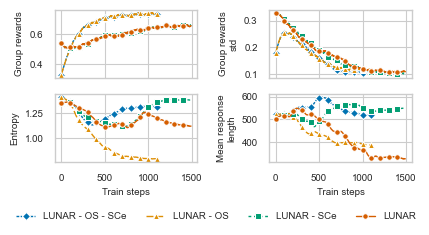

In [13]:
fontsize = 7
linewidth = 1
markersize = 4

# Define line styles
dashes = {
    'LUNAR': '',                    # solid line
    'LUNAR - SCe': (2, 2),         # short dashes
    'LUNAR - OS': (5, 2),          # longer dashes
    'LUNAR - OS - SCe': (2, 1, 1, 1),  # dash-dot pattern
}

# Define markers
markers = {
    'LUNAR': 'o',              # circle
    'LUNAR - SCe': 's',        # square
    'LUNAR - OS': '^',         # triangle
    'LUNAR - OS - SCe': 'D',   # diamond
}

fig, axes = plt.subplots(2, 2, figsize=(4.3, 2.3), sharex=True, constrained_layout=False)

# (0,0) Reward
sns.lineplot(
    data=reward_long,
    x="train/global_step",
    y="Group rewards",
    hue="Variant",
    hue_order=order,
    palette="colorblind",
    style="Variant",
    style_order=order,
    dashes=dashes,
    markers=markers,
    markevery=100,  # Show marker every 100 data points
    markersize=markersize,
    linewidth=linewidth,
    ax=axes[0, 0],
)

# Grab handles/labels from the legend seaborn created on (0,0), then remove it
handles, labels = axes[0, 0].get_legend_handles_labels()
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].set_ylabel("Group rewards", fontsize=fontsize)

# (0,1) Reward std
sns.lineplot(
    data=reward_std_long,
    x="train/global_step",
    y="Group rewards std",
    hue="Variant",
    hue_order=order,
    palette="colorblind",
    style="Variant",
    style_order=order,
    dashes=dashes,
    markers=markers,
    markevery=100,
    markersize=markersize,
    linewidth=linewidth,
    ax=axes[0, 1],
    legend=False,
)
axes[0, 1].set_ylabel("Group rewards\nstd", fontsize=fontsize)

# (1,0) Entropy
sns.lineplot(
    data=entropy_long,
    x="train/global_step",
    y="Entropy",
    hue="Variant",
    hue_order=order,
    palette="colorblind",
    style="Variant",
    style_order=order,
    dashes=dashes,
    markers=markers,
    markevery=100,
    markersize=markersize,
    linewidth=linewidth,
    ax=axes[1, 0],
    legend=False,
)
axes[1, 0].set_ylabel("Entropy", fontsize=fontsize)

# (1,1) Mean length
sns.lineplot(
    data=length_long,
    x="train/global_step",
    y="Mean response length",
    hue="Variant",
    hue_order=order,
    palette="colorblind",
    style="Variant",
    style_order=order,
    dashes=dashes,
    markers=markers,
    markevery=100,
    markersize=markersize,
    linewidth=linewidth,
    ax=axes[1, 1],
    legend=False,
)
axes[1, 1].set_ylabel("Mean response\nlength", fontsize=fontsize)

axes[1, 0].set_xlabel("Train steps", fontsize=fontsize)
axes[1, 1].set_xlabel("Train steps", fontsize=fontsize)

# Tick label sizes (iterate over all axes correctly)
for ax in axes.ravel():
    ax.tick_params(axis="both", labelsize=fontsize)

# ----------------------------
# Bottom, figure-level legend
# ----------------------------
# Filter to the variants in your specified order (and avoid extra labels seaborn may add)
label_to_handle = {lab: h for h, lab in zip(handles, labels)}
legend_handles = [label_to_handle[l] for l in order if l in label_to_handle]
legend_labels = [l for l in order if l in label_to_handle]

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="lower center",
    ncol=len(legend_labels),
    frameon=False,
    fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.02),
)

# Leave space at the bottom for legend
fig.tight_layout(rect=[0, 0.06, 1, 1])
# plt.show()
fig.savefig("../figures/fig2_train_plot.pdf", dpi=200, format="pdf", bbox_inches="tight")